<a href="https://colab.research.google.com/github/Roshanreddy03/Titanic-data-set/blob/main/EDA_project_on_kaggle_titanic_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overview of Titanic dataset project**

1. Basic Counts (Who was on the ship)

   -> Use a histogram for the distribution of ages.

   -> Use a histogram for the distribution of ticket prices.

   -> Use bar plots for total counts of gender, passenger class, and boarding port.

2. Survival Factors (Who survived)

   -> Use bar plots for survival rates by gender.

   -> Use bar plots for survival rates by passenger class.

3. Advanced Trends (Digging deeper)

   -> Use a grouped bar plot for survival by both class and gender at the same time.

Load the dataset using pandas

In [ ]:
import sqlite3
import pandas as pd
# create a new database
conn = sqlite3.connect("EDA_database.db")

df=pd.read_csv("titanic.csv")
df.to_sql("titanic.csv",conn,if_exists="replace",index=False)

print("Table created successfully !")

Table created successfully !


In [ ]:
import seaborn as sns
# Load data set
titanic=sns.load_dataset('titanic')
titanic.to_sql('titanic',conn, if_exists='replace',index=False)

print(titanic.to_sql)

<bound method NDFrame.to_sql of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [ ]:
titanic.shape

(891, 15)

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
conn = sqlite3.connect("EDA_database.db")

query="SELECT survived,pclass,sex,age FROM titanic"
df_sql=pd.read_sql(query, conn)

print(df_sql)
conn.close()

     survived  pclass     sex   age
0           0       3    male  22.0
1           1       1  female  38.0
2           1       3  female  26.0
3           1       1  female  35.0
4           0       3    male  35.0
..        ...     ...     ...   ...
886         0       2    male  27.0
887         1       1  female  19.0
888         0       3  female   NaN
889         1       1    male  26.0
890         0       3    male  32.0

[891 rows x 4 columns]


Bar Chart (Count of Survivors)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

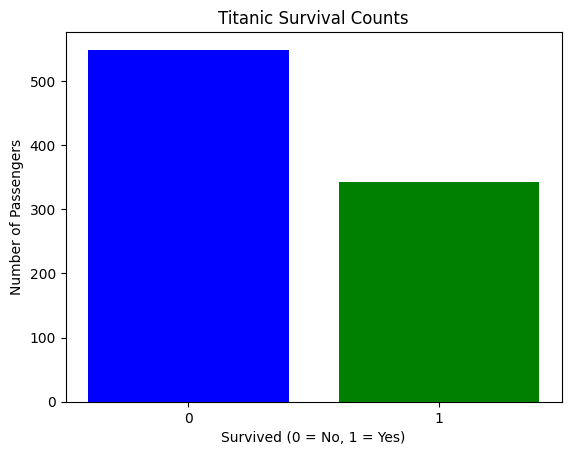

In [ ]:
# Passengers: survived (1) and died (0)
survival_counts = df['Survived'].value_counts()

# Create the bar chart
plt.bar(survival_counts.index, survival_counts.values, color=['blue', 'green'])

plt.title('Titanic Survival Counts')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.xticks([0, 1])

plt.show()

Histogram (Distribution of Ages)

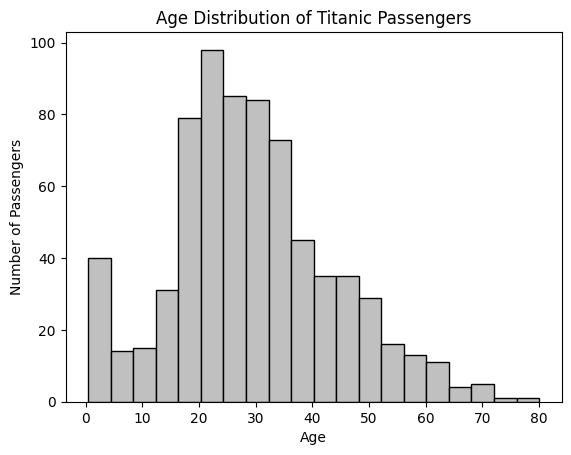

In [ ]:
# Create the histogram.
# We use .dropna() because matplotlib will throw an error if there are missing Age values.
plt.hist(df['Age'].dropna(), bins=20, color='silver', edgecolor='black')

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

1. Bar Plot: Survival by Gender (Categorical)

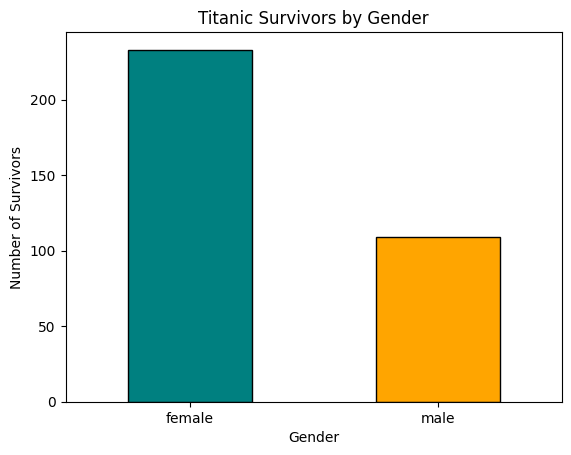

In [ ]:
# 1. Filter the dataset to isolate only the passengers who survived
survivors = df[df['Survived'] == 1]

# 2. Count how many survivors were male vs. female
gender_counts = survivors['Sex'].value_counts()

# 3. Create the bar plot directly from the pandas count data
gender_counts.plot(kind='bar', color=['teal', 'orange'], edgecolor='black')

# 4. Add Matplotlib labels
plt.title('Titanic Survivors by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Survivors')
plt.xticks(rotation=0) # Keeps the "male"/"female" labels horizontal

plt.show()

2. Bar Plot: Survival by Passenger Class (Categorical)

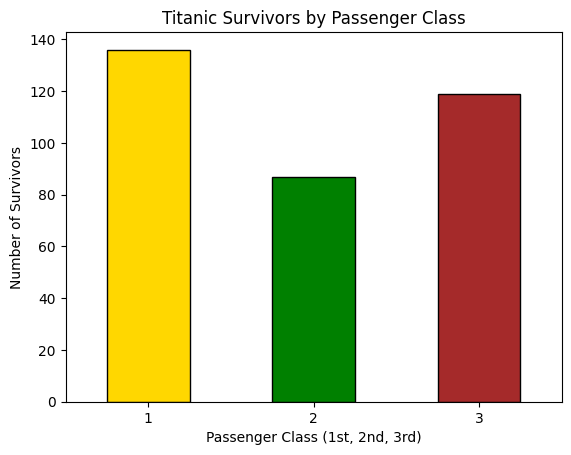

In [ ]:
# 1. Count how many survivors were in each passenger class (Pclass)
class_counts = survivors['Pclass'].value_counts()

# 2. Sort the index so it displays 1st, 2nd, 3rd class in logical order
class_counts = class_counts.sort_index()

# 3. Create the bar plot
class_counts.plot(kind='bar', color=['gold', 'green', 'brown'], edgecolor='black')

# 4. Add Matplotlib labels
plt.title('Titanic Survivors by Passenger Class')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Number of Survivors')
plt.xticks(rotation=0)

plt.show()

3. Bar Plot: Survival by both class and gender

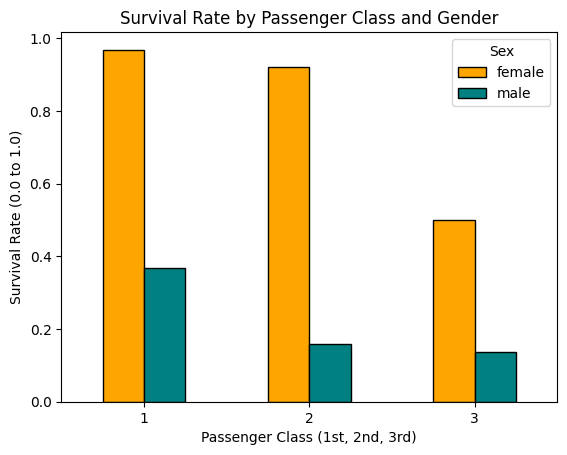

In [ ]:
# 1. Group the data by Class (rows) and Gender (columns)
survival_rates = df.pivot_table(index='Pclass', columns='Sex', values='Survived')

# 2. Create the grouped bar plot
survival_rates.plot(kind='bar', color=['orange', 'teal'], edgecolor='black')

import matplotlib.pyplot as plt
plt.title('Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Survival Rate (0.0 to 1.0)')
plt.xticks(rotation=0)

plt.show()